## TC 5033
### Word Embeddings

<br>

#### Activity 3a: Exploring Word Embeddings with GloVe and Numpy
<br>

- Objective:
    - To understand the concept of word embeddings and their significance in Natural Language Processing.
    - To learn how to manipulate and visualize high-dimensional data using dimensionality reduction techniques like PCA and t-SNE.
    - To gain hands-on experience in implementing word similarity and analogies using GloVe embeddings and Numpy.
    
<br>

- Instructions:
    - Download GloVe pre-trained vectors from the provided link in Canvas, the official public project: 
    Jeffrey Pennington, Richard Socher, and Christopher D. Manning. 2014. GloVe: Global Vectors for Word Representation
    https://nlp.stanford.edu/data/glove.6B.zip

    - Create a dictorionay of the embeddings so that you carry out fast look ups. Save that dictionary e.g. as a serialized file for faster loading in future uses.
    
    - PCA and t-SNE Visualization: After loading the GloVe embeddings, use Numpy and Sklearn to perform PCA and t-SNE to reduce the dimensionality of the embeddings and visualize them in a 2D or 3D space.

    - Word Similarity: Implement a function that takes a word as input and returns the 'n' most similar words based on their embeddings. You should use Numpy to implement this function, using libraries that already implement this function (e.g. Gensim) will result in zero points.

    - Word Analogies: Implement a function to solve analogies between words. For example, "man is to king as woman is to ____". You should use Numpy to implement this function, using libraries that already implement this function (e.g. Gensim) will result in zero points.

    - Submission: This activity is to be submitted in teams of 3 or 4. Only one person should submit the final work, with the full names of all team members included in a markdown cell at the beginning of the notebook.
    
<br>

- Evaluation Criteria:

    - Code Quality (40%): Your code should be well-organized, clearly commented, and easy to follow. Use also markdown cells for clarity.
    
   - Functionality (60%): All functions should work as intended, without errors.
       - Visualization of PCA and t-SNE (10% each for a total of 20%)
       - Similarity function (20%)
       - Analogy function (20%)
|



# Team 48

* Leonardo Daniel Rodríguez Vega – A01797465

* Rigoberto Bracamontes Salazar – A01134473

* Mayra Judith Vargas Rivero – A01797375

* Oliver Jordy Pérez Escamilla – A01797471

#### Import libraries

In [ ]:
# --- Import libraries ---
import torch                          # PyTorch (used elsewhere; kept for compatibility)
import torch.nn.functional as F       # Functional API (e.g. cosine_similarity, though we use NumPy here)
from sklearn.manifold import TSNE     # t-SNE for non-linear dimensionality reduction
from sklearn.decomposition import PCA # PCA for linear dimensionality reduction
import matplotlib.pyplot as plt       # Plotting
import numpy as np                    # Numerical operations on embedding vectors
from numpy.linalg import norm         # L2 norm — used in cosine similarity
import pickle                         # Serialise / deserialise the embeddings dictionary

plt.style.use('ggplot')               # Use the ggplot visual style for all plots

#### Load file

#### Loading GloVe Embeddings

GloVe (Global Vectors for Word Representation) provides pre-trained word vectors. Each line in the text file contains a word followed by its vector components, separated by spaces. We parse this into a Python dictionary for O(1) look-ups by word, and optionally serialise it with `pickle` so future loads are faster.

In [ ]:
# Path to the pre-trained GloVe embeddings file (50-dimensional vectors)
# Download from: https://nlp.stanford.edu/data/glove.6B.zip
PATH = '/Users/oliverperez/Documents/Tec/MNA/Advanced Machine Learning/DB/glove_embeddings/glove.6B.50d.txt'

# Dimensionality of the embedding vectors (must match the file: 50d, 100d, 200d, or 300d)
emb_dim = 50

In [32]:
# Create dictionary with embeddings
def create_emb_dictionary(path):
    """
    Reads a GloVe embeddings file and returns a dictionary
    mapping each word (str) to its embedding vector (np.array).
    """
    embeddings_dict = {}
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            vector = np.array(values[1:], dtype='float32')
            embeddings_dict[word] = vector
    return embeddings_dict

In [ ]:
# Build the embeddings dictionary from the GloVe file.
# This scans the entire file once and stores ~400 000 word→vector mappings in memory.
embeddings_dict = create_emb_dictionary(PATH)

In [ ]:
# Serialize the dictionary to a .pkl file for faster loading in future sessions.
# pickle.dump writes the Python object in binary format.
with open('embeddings_dict_50D.pkl', 'wb') as f:
    pickle.dump(embeddings_dict, f)

# To load later without re-parsing the GloVe text file, uncomment:
# with open('embeddings_dict_50D.pkl', 'rb') as f:
#     embeddings_dict = pickle.load(f)

#### See some embeddings

In [ ]:
# Utility function to peek at the raw GloVe file.
# Prints the first n_words+1 lines (word + all vector components) so we
# can verify the format and confirm the expected embedding dimension.
def show_n_first_words(path, n_words):
    with open(path, 'r') as f:
        for i, line in enumerate(f):
            parts = line.split()
            print(parts, len(parts[1:]))   # parts[0] = word, parts[1:] = vector values
            if i >= n_words:
                break

In [ ]:
# Display the first 6 entries from the GloVe file to inspect format
show_n_first_words(PATH, 5)

['the', '0.418', '0.24968', '-0.41242', '0.1217', '0.34527', '-0.044457', '-0.49688', '-0.17862', '-0.00066023', '-0.6566', '0.27843', '-0.14767', '-0.55677', '0.14658', '-0.0095095', '0.011658', '0.10204', '-0.12792', '-0.8443', '-0.12181', '-0.016801', '-0.33279', '-0.1552', '-0.23131', '-0.19181', '-1.8823', '-0.76746', '0.099051', '-0.42125', '-0.19526', '4.0071', '-0.18594', '-0.52287', '-0.31681', '0.00059213', '0.0074449', '0.17778', '-0.15897', '0.012041', '-0.054223', '-0.29871', '-0.15749', '-0.34758', '-0.045637', '-0.44251', '0.18785', '0.0027849', '-0.18411', '-0.11514', '-0.78581'] 50
[',', '0.013441', '0.23682', '-0.16899', '0.40951', '0.63812', '0.47709', '-0.42852', '-0.55641', '-0.364', '-0.23938', '0.13001', '-0.063734', '-0.39575', '-0.48162', '0.23291', '0.090201', '-0.13324', '0.078639', '-0.41634', '-0.15428', '0.10068', '0.48891', '0.31226', '-0.1252', '-0.037512', '-1.5179', '0.12612', '-0.02442', '-0.042961', '-0.28351', '3.5416', '-0.11956', '-0.014533', '-0.

### Dimensionality Reduction & Visualisation

GloVe embeddings live in a 50-dimensional space — far too many dimensions to visualise directly. We use two techniques to project them down to 2-D:

- **PCA (Principal Component Analysis)**: a *linear* method that finds the 2 directions of maximum variance. Fast, but may miss non-linear structure.
- **t-SNE (t-distributed Stochastic Neighbour Embedding)**: a *non-linear* method optimised to preserve local neighbourhoods. Produces tighter semantic clusters but is slower and non-deterministic.

Both methods let us visually confirm that semantically related words (e.g. countries, fruits) are grouped together in embedding space.

### Plot some embeddings

In [37]:
def plot_embeddings(emb_path, words2show, emb_dim, embeddings_dict, func=PCA):
    """
    Reduces word embeddings to 2D using the given dimensionality reduction
    function (PCA or TSNE) and plots them as a labeled scatter plot.
    """
    # Build a matrix of embeddings for the selected words
    vectors = np.array([embeddings_dict[word] for word in words2show])

    # Apply dimensionality reduction to 2 components
    reducer = func(n_components=2)
    reduced = reducer.fit_transform(vectors)

    # Plot
    plt.figure(figsize=(14, 10))
    plt.scatter(reduced[:, 0], reduced[:, 1], edgecolors='black', linewidths=0.5)
    for i, word in enumerate(words2show):
        plt.annotate(word, xy=(reduced[i, 0], reduced[i, 1]),
                     fontsize=12, ha='center', va='bottom')
    plt.title(f'Word Embeddings — {func.__name__} projection', fontsize=16)
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')
    plt.tight_layout()
    plt.show()

    return reduced

In [ ]:
# A curated list of words from different semantic categories:
#   food, countries, beverages, fruits, and education.
# We expect PCA/t-SNE to cluster words from the same category together.
words = ['burger', 'tortilla', 'bread', 'pizza', 'beef', 'steak', 'fries', 'chips',
         'argentina', 'mexico', 'spain', 'usa', 'france', 'italy', 'greece', 'china',
         'water', 'beer', 'tequila', 'wine', 'whisky', 'brandy', 'vodka', 'coffee', 'tea',
         'apple', 'banana', 'orange', 'lemon', 'grapefruit', 'grape', 'strawberry', 'raspberry',
         'school', 'work', 'university', 'highschool']


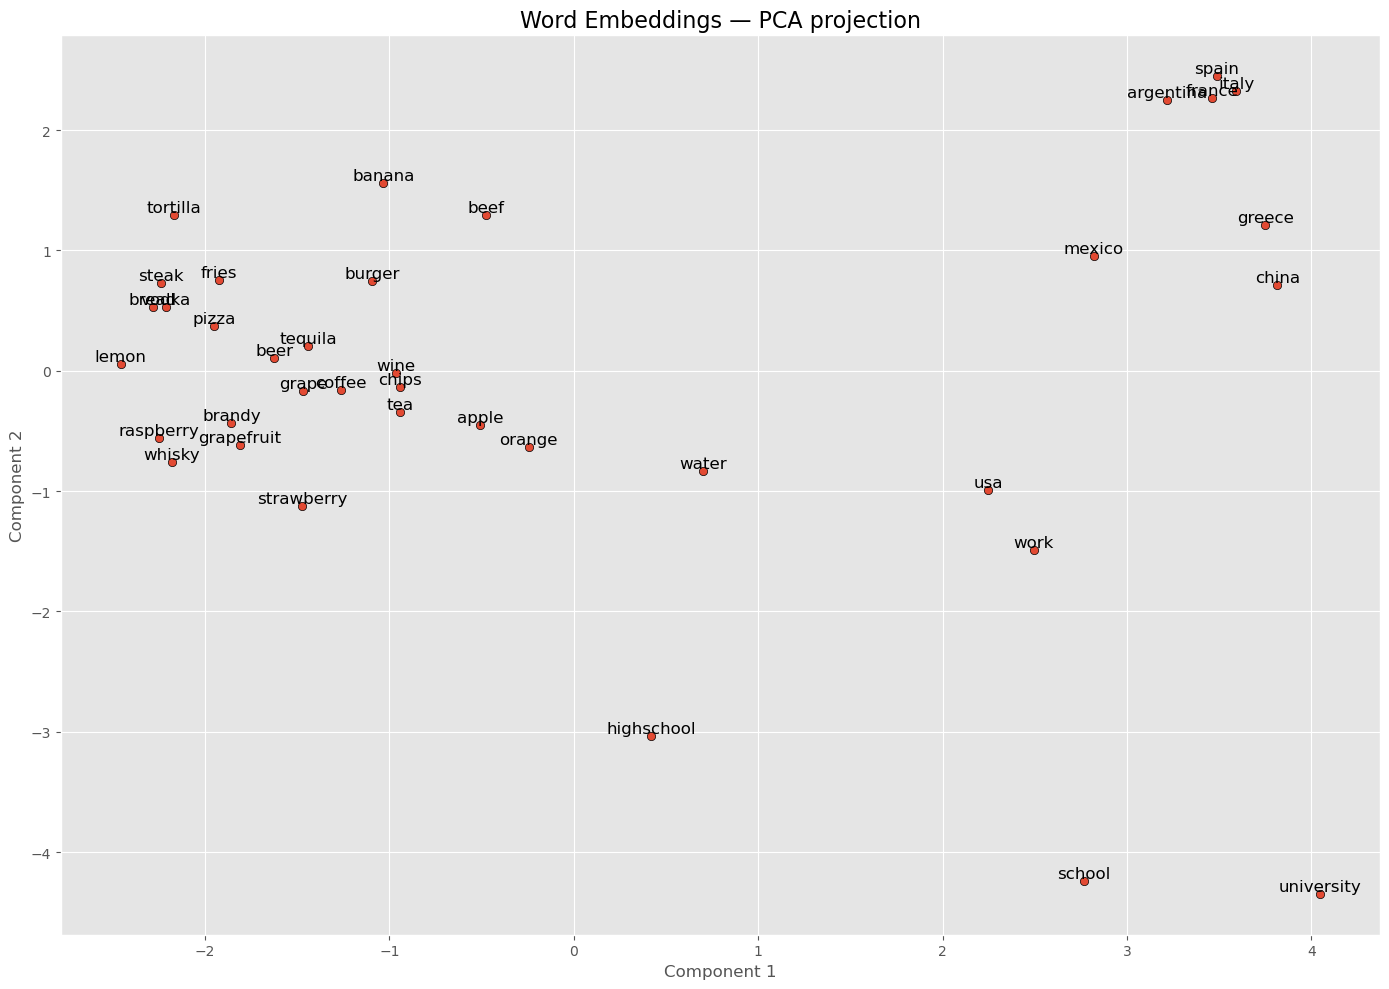

array([[-1.0925044 ,  0.74372864],
       [-2.1670642 ,  1.2923661 ],
       [-2.2834148 ,  0.52902013],
       [-1.9500185 ,  0.3721771 ],
       [-0.47766292,  1.2940507 ],
       [-2.2378073 ,  0.7307424 ],
       [-1.92657   ,  0.7556914 ],
       [-0.9450017 , -0.13504958],
       [ 3.219376  ,  2.2466915 ],
       [ 2.8189163 ,  0.95552117],
       [ 3.4881315 ,  2.4482496 ],
       [ 2.247281  , -0.99435824],
       [ 3.4618905 ,  2.2692263 ],
       [ 3.5916219 ,  2.3245137 ],
       [ 3.750168  ,  1.211539  ],
       [ 3.8158367 ,  0.71475947],
       [ 0.6991156 , -0.8325447 ],
       [-1.6239517 ,  0.10265314],
       [-1.439923  ,  0.20648363],
       [-0.9629107 , -0.02196904],
       [-2.1817417 , -0.7590342 ],
       [-1.8575071 , -0.43355265],
       [-2.2137516 ,  0.52904814],
       [-1.2642857 , -0.15639074],
       [-0.9421789 , -0.34516907],
       [-0.5101743 , -0.45191365],
       [-1.033432  ,  1.5628412 ],
       [-0.24471137, -0.63604486],
       [-2.4575226 ,

In [ ]:
# PCA dimensionality reduction: projects the 50-D embeddings onto the 2 directions
# of greatest variance.  Good for seeing the overall linear structure.
plot_embeddings(PATH, words, emb_dim, embeddings_dict, PCA)

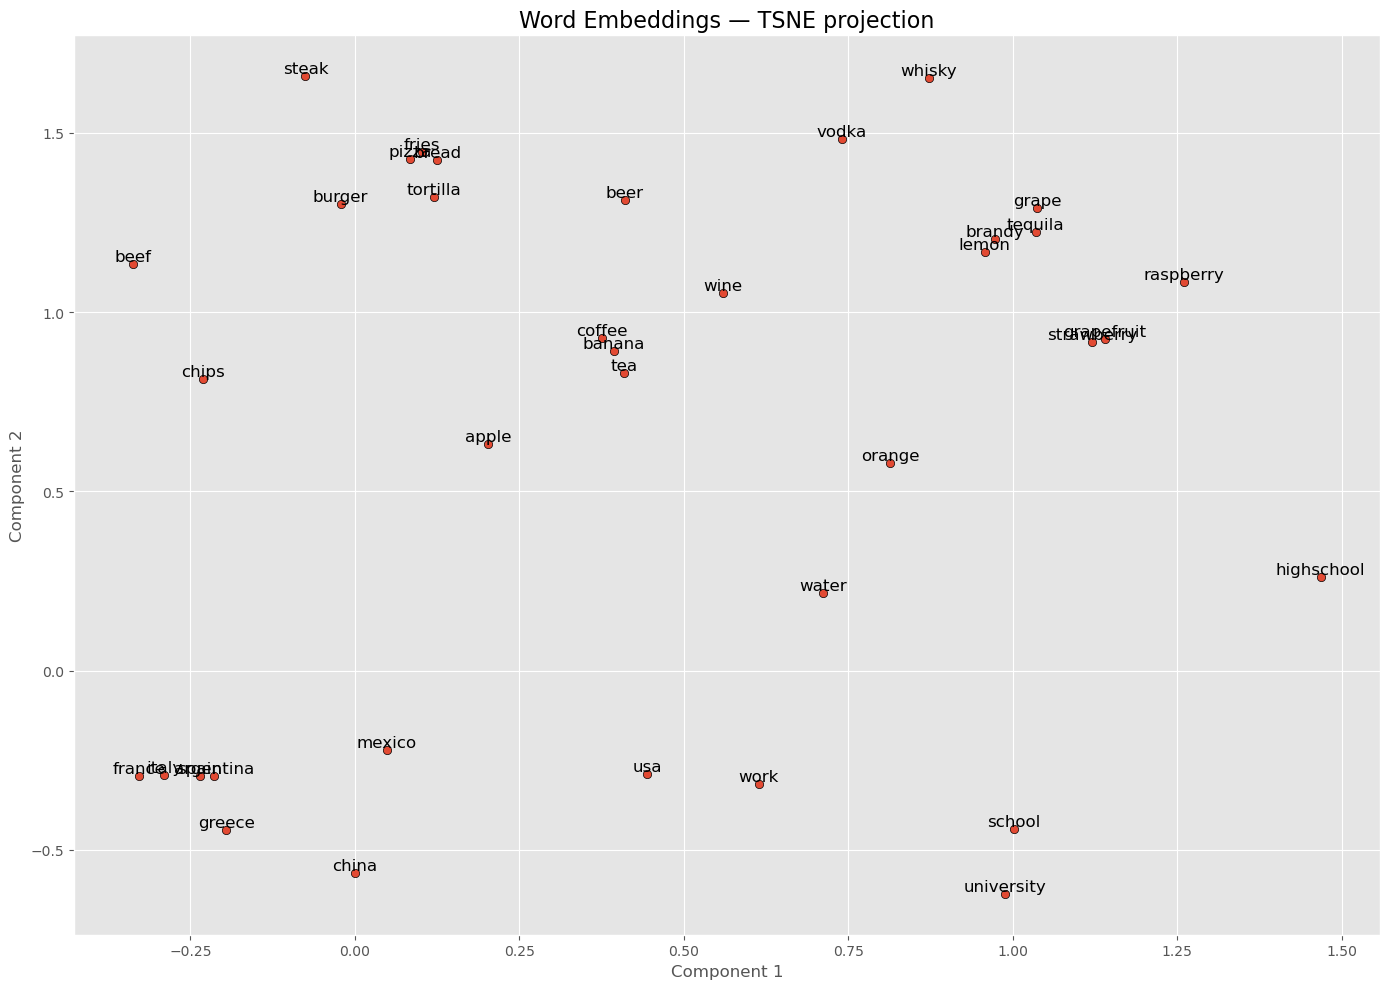

In [ ]:
# t-SNE dimensionality reduction: a non-linear technique that preserves local
# neighbourhood structure — words that are close in 50-D space stay close in 2-D.
# Tends to form tighter clusters than PCA.
embeddings = plot_embeddings(PATH, words, emb_dim, embeddings_dict, TSNE)

### Word Analogies

Word analogies exploit the linear structure of embedding space. The classic example is:

> *"man is to king as woman is to ___?"*

We compute the **analogy vector**: `king − man + woman` and find the word whose embedding is closest (by cosine similarity) to that result. The answer should be **queen**.

This works because the direction `king − man` captures the concept of *royalty*, and adding it to `woman` lands near `queen`.

### Let us compute analogies

In [41]:
# analogy
def analogy(word1, word2, word3, embeddings_dict):
    """
    Solves: word1 is to word2 as word3 is to ___?
    Computes: vec = word2 - word1 + word3
    Returns the word whose embedding is most similar (cosine) to vec,
    excluding the three input words.
    """
    # Compute the analogy vector
    vec = embeddings_dict[word2] - embeddings_dict[word1] + embeddings_dict[word3]

    best_word = None
    best_similarity = -np.inf
    exclude = {word1, word2, word3}

    for word, emb in embeddings_dict.items():
        if word in exclude:
            continue
        # Cosine similarity
        similarity = np.dot(vec, emb) / (norm(vec) * norm(emb))
        if similarity > best_similarity:
            best_similarity = similarity
            best_word = word

    print(f'{word1} is to {word2} as {word3} is to {best_word}')
    return best_word

In [ ]:
# Classic analogy test: "man is to king as woman is to ___?"
# Expected answer: queen  (king - man + woman ≈ queen)
analogy('man', 'king', 'woman', embeddings_dict)

man is to king as woman is to queen


'queen'

### Word Similarity

Given a query word, we find the *n* most similar words in the entire vocabulary by computing the **cosine similarity** between the query vector and every other vector:

$$\text{cosine\_sim}(\mathbf{a}, \mathbf{b}) = \frac{\mathbf{a} \cdot \mathbf{b}}{\|\mathbf{a}\| \, \|\mathbf{b}\|}$$

A similarity of 1 means the vectors point in the same direction (identical meaning), while 0 means they are orthogonal (unrelated).

In [43]:
# most similar
def find_most_similar(word, embeddings_dict, top_n=10):
    """
    Finds the top_n most similar words to the given word
    using cosine similarity computed with NumPy.
    Returns a list of (word, similarity) tuples sorted by descending similarity.
    """
    target_vec = embeddings_dict[word]
    target_norm = norm(target_vec)

    similarities = []
    for w, emb in embeddings_dict.items():
        if w == word:
            continue
        # Cosine similarity
        sim = np.dot(target_vec, emb) / (target_norm * norm(emb))
        similarities.append((w, sim))

    # Sort by similarity descending and return the top_n results
    similarities.sort(key=lambda x: x[1], reverse=True)
    return similarities[:top_n]

In [ ]:
# Find the 10 words whose GloVe vectors are closest to "mexico" (by cosine similarity)
most_similar = find_most_similar('mexico', embeddings_dict)

In [ ]:
# Print the ranked list of most similar words
for i, w in enumerate(most_similar, 1):
    print(f'{i} ---> {w[0]}')

1 ---> mexican
2 ---> venezuela
3 ---> colombia
4 ---> peru
5 ---> chile
6 ---> puerto
7 ---> rico
8 ---> cuba
9 ---> guatemala
10 ---> panama
